In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4
GPU memory      : 15.6 GB


In [4]:
# ── Update these paths after adding the ISIC dataset on Kaggle ──
IMAGE_DIR = '/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input'
MASK_DIR  = '/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth'

images = sorted(os.listdir(IMAGE_DIR))
masks  = sorted(os.listdir(MASK_DIR))
print(f"Total images : {len(images)}")
print(f"Total masks  : {len(masks)}")
print(f"\nSample image : {images[0]}")
print(f"Sample mask  : {masks[0]}")

Total images : 2596
Total masks  : 2596

Sample image : ATTRIBUTION.txt
Sample mask  : ATTRIBUTION.txt


Total images : 2594
Total masks  : 2594


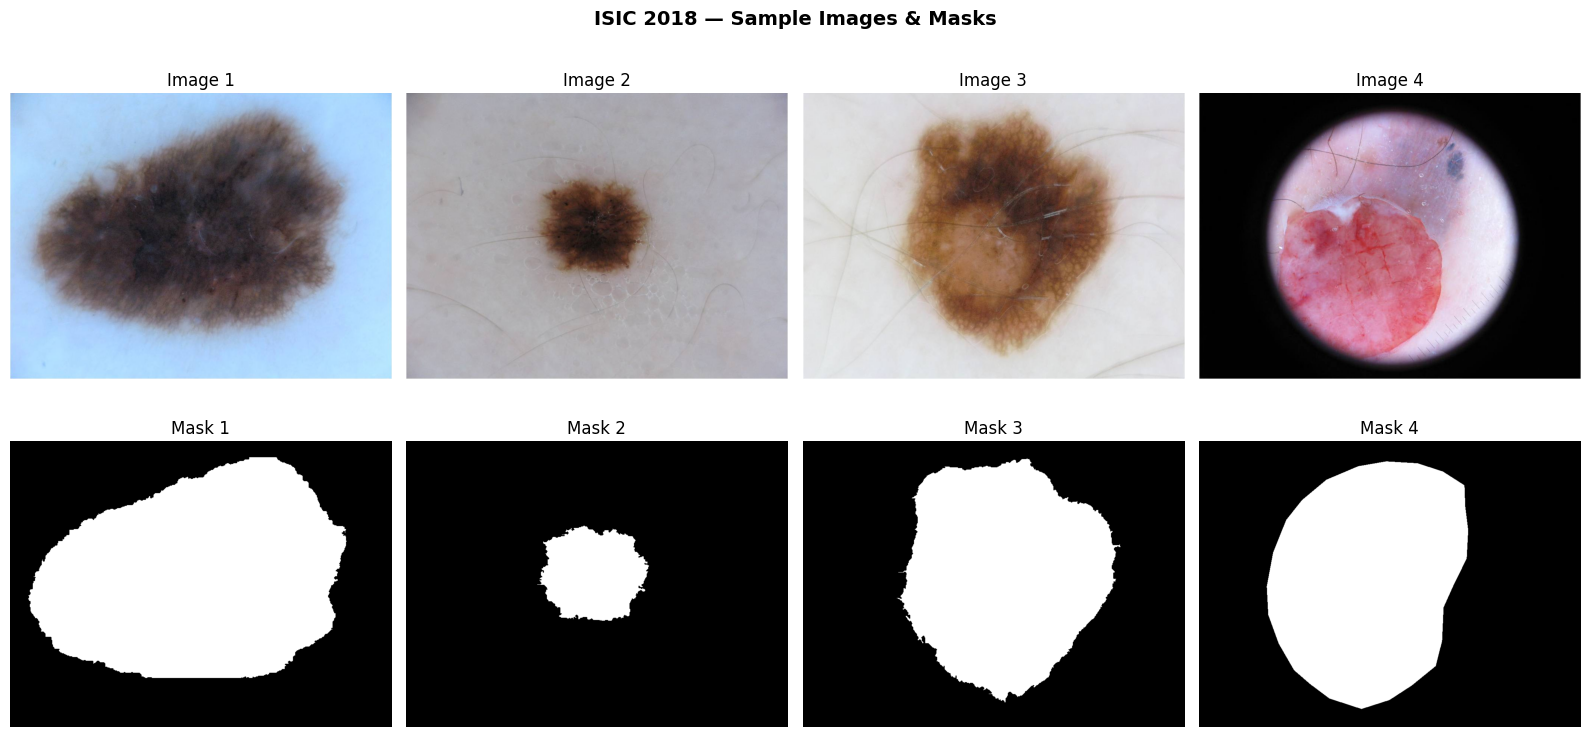

Image size: (1022, 767) | Mask size: (1022, 767)


In [5]:
from PIL import Image

# Filter only image files (excludes .txt and other non-image files)
images = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg') or f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_DIR)  if f.endswith('.png')])

print(f"Total images : {len(images)}")
print(f"Total masks  : {len(masks)}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('ISIC 2018 — Sample Images & Masks', fontsize=14, fontweight='bold')

for col in range(4):
    img_path  = os.path.join(IMAGE_DIR, images[col])
    stem      = os.path.splitext(images[col])[0]
    mask_path = os.path.join(MASK_DIR, stem + '_segmentation.png')

    img  = Image.open(img_path)
    mask = Image.open(mask_path)

    axes[0, col].imshow(img);               axes[0, col].set_title(f'Image {col+1}'); axes[0, col].axis('off')
    axes[1, col].imshow(mask, cmap='gray'); axes[1, col].set_title(f'Mask {col+1}');  axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_data.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Image size: {img.size} | Mask size: {mask.size}")

In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


# ─────────────────────────────────────────────
#  Dataset
# ─────────────────────────────────────────────
class ISICDataset(Dataset):
    """
    Loads ISIC 2018 images and binary segmentation masks.
    Masks are binarized: 0 (background) or 1 (lesion).
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith('.jpg') or f.endswith('.png')
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name  = self.images[idx]
        stem      = os.path.splitext(img_name)[0]
        img_path  = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, stem + '_segmentation.png')

        image = np.array(Image.open(img_path).convert('RGB'))
        mask  = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)
        mask  = (mask > 127).astype(np.float32)   # binarize: 0.0 or 1.0

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].unsqueeze(0)       # (1, H, W)

        return image, mask


# ─────────────────────────────────────────────
#  Augmentation Pipelines
# ─────────────────────────────────────────────
def get_train_transforms(img_size=256):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=15, p=0.4),
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.2, hue=0.1, p=0.4),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

def get_val_transforms(img_size=256):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


# ─────────────────────────────────────────────
#  DataLoader Factory
# ─────────────────────────────────────────────
def get_loaders(image_dir, mask_dir, img_size=256,
                batch_size=16, val_split=0.15,
                num_workers=2, seed=42):
    all_images = sorted([
        f for f in os.listdir(image_dir)
        if f.endswith('.jpg') or f.endswith('.png')
    ])
    train_imgs, val_imgs = train_test_split(
        all_images, test_size=val_split, random_state=seed
    )

    train_ds = ISICDataset(image_dir, mask_dir, transform=get_train_transforms(img_size))
    val_ds   = ISICDataset(image_dir, mask_dir, transform=get_val_transforms(img_size))
    train_ds.images = train_imgs
    val_ds.images   = val_imgs

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              persistent_workers=True, prefetch_factor=2)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True,
                              persistent_workers=True, prefetch_factor=2)

    print(f"Train samples : {len(train_ds)}")
    print(f"Val samples   : {len(val_ds)}")
    return train_loader, val_loader, val_imgs


print("✅ Dataset & augmentation classes defined")

✅ Dataset & augmentation classes defined


In [7]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torchvision.models as models


# class ConvBlock(nn.Module):
#     """Two consecutive Conv → BN → ReLU layers (core U-Net block)."""
#     def __init__(self, in_ch, out_ch):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
#             nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
#             nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
#             nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
#         )
#     def forward(self, x):
#         return self.block(x)


# class UpBlock(nn.Module):
#     """Upsample → concat skip connection → ConvBlock."""
#     def __init__(self, in_ch, skip_ch, out_ch):
#         super().__init__()
#         self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
#         self.conv = ConvBlock(in_ch // 2 + skip_ch, out_ch)

#     def forward(self, x, skip):
#         x = self.up(x)
#         # ✅ Fix: pad x if spatial size doesn't exactly match skip
#         if x.shape != skip.shape:
#             x = F.pad(x, [0, skip.shape[3] - x.shape[3],
#                           0, skip.shape[2] - x.shape[2]])
#         x = torch.cat([x, skip], dim=1)
#         return self.conv(x)


# class UNet(nn.Module):
#     def __init__(self, num_classes=1, pretrained=True):
#         super().__init__()
#         backbone = models.resnet34(
#             weights=models.ResNet34_Weights.DEFAULT if pretrained else None
#         )
#         self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
#         self.pool = backbone.maxpool
#         self.enc1 = backbone.layer1
#         self.enc2 = backbone.layer2
#         self.enc3 = backbone.layer3
#         self.enc4 = backbone.layer4

#         self.bottleneck = ConvBlock(512, 1024)

#         self.dec4 = UpBlock(1024, 512, 512)
#         self.dec3 = UpBlock(512,  256, 256)
#         self.dec2 = UpBlock(256,  128, 128)
#         self.dec1 = UpBlock(128,   64,  64)

#         self.up_final   = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
#         self.final_conv = nn.Conv2d(32 + 64, num_classes, kernel_size=1)

#     def forward(self, x):
#         e0 = self.enc0(x)
#         p  = self.pool(e0)
#         e1 = self.enc1(p)
#         e2 = self.enc2(e1)
#         e3 = self.enc3(e2)
#         e4 = self.enc4(e3)
#         b  = self.bottleneck(e4)
#         d4 = self.dec4(b,  e4)
#         d3 = self.dec3(d4, e3)
#         d2 = self.dec2(d3, e2)
#         d1 = self.dec1(d2, e1)

#         up = self.up_final(d1)
#         # ✅ Fix: pad up if size doesn't match e0
#         if up.shape != e0.shape:
#             up = F.pad(up, [0, e0.shape[3] - up.shape[3],
#                             0, e0.shape[2] - up.shape[2]])
#         return self.final_conv(torch.cat([up, e0], dim=1))


# # Sanity check
# with torch.no_grad():
#     _m   = UNet(pretrained=False)
#     _x   = torch.randn(2, 3, 256, 256)
#     _out = _m(_x)
#     print(f"✅ U-Net output shape: {_out.shape}")   # (2, 1, 256, 256)
#     del _m, _x, _out

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.pad(x, [0, skip.shape[3] - x.shape[3],
                          0, skip.shape[2] - x.shape[2]])
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        backbone = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT if pretrained else None
        )
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # 64,  H/2
        self.pool = backbone.maxpool                                              # 64,  H/4
        self.enc1 = backbone.layer1   # 64,  H/4
        self.enc2 = backbone.layer2   # 128, H/8
        self.enc3 = backbone.layer3   # 256, H/16
        self.enc4 = backbone.layer4   # 512, H/32

        self.bottleneck = ConvBlock(512, 1024)

        self.dec4 = UpBlock(1024, 512, 512)   # H/32 → H/16
        self.dec3 = UpBlock(512,  256, 256)   # H/16 → H/8
        self.dec2 = UpBlock(256,  128, 128)   # H/8  → H/4
        self.dec1 = UpBlock(128,   64,  64)   # H/4  → H/2  (skip=enc1, 64ch)

        # ✅ Two separate upsamples to go H/2 → H/2 (with enc0 skip) → H
        self.up_to_half  = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)   # H/2 → H ... wait
        # Actually: dec1 output is H/2, enc0 is also H/2, so we cat then upsample to H
        self.skip_conv   = ConvBlock(64 + 64, 64)   # merge dec1 + enc0
        self.up_final    = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)   # H/2 → H
        self.final_conv  = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        e0 = self.enc0(x)       # (B, 64,  H/2, W/2)
        p  = self.pool(e0)      # (B, 64,  H/4, W/4)
        e1 = self.enc1(p)       # (B, 64,  H/4, W/4)
        e2 = self.enc2(e1)      # (B, 128, H/8, W/8)
        e3 = self.enc3(e2)      # (B, 256, H/16,W/16)
        e4 = self.enc4(e3)      # (B, 512, H/32,W/32)

        b  = self.bottleneck(e4)

        d4 = self.dec4(b,  e4)  # (B, 512, H/16,W/16)
        d3 = self.dec3(d4, e3)  # (B, 256, H/8, W/8)
        d2 = self.dec2(d3, e2)  # (B, 128, H/4, W/4)
        d1 = self.dec1(d2, e1)  # (B, 64,  H/2, W/2)

        # Merge with enc0 skip (both are H/2) then upsample to H
        if d1.shape[2:] != e0.shape[2:]:
            d1 = F.pad(d1, [0, e0.shape[3] - d1.shape[3],
                            0, e0.shape[2] - d1.shape[2]])
        merged = self.skip_conv(torch.cat([d1, e0], dim=1))  # (B, 64, H/2, W/2)
        up     = self.up_final(merged)                        # (B, 32, H,   W)
        return self.final_conv(up)                            # (B, 1,  H,   W)


# Sanity check
with torch.no_grad():
    _m   = UNet(pretrained=False)
    _x   = torch.randn(2, 3, 256, 256)
    _out = _m(_x)
    print(f"✅ U-Net output shape: {_out.shape}")  # must be (2, 1, 256, 256)
    del _m, _x, _out

✅ U-Net output shape: torch.Size([2, 1, 256, 256])


In [9]:
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """Measures overlap. Better than BCE alone for imbalanced masks."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        inter   = (probs * targets).sum()
        return 1.0 - (2.0 * inter + self.smooth) / (probs.sum() + targets.sum() + self.smooth)


class BCEDiceLoss(nn.Module):
    """
    BCE + Dice combined — industry standard for medical segmentation.
    BCE  → per-pixel accuracy
    Dice → region overlap
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.w_bce  = bce_weight
        self.w_dice = dice_weight
        self.bce    = nn.BCEWithLogitsLoss()
        self.dice   = DiceLoss()
    def forward(self, logits, targets):
        return self.w_bce * self.bce(logits, targets) + self.w_dice * self.dice(logits, targets)


def dice_score(logits, targets, thr=0.5, smooth=1.0):
    """Dice / F1 score. Range: 0 → 1 (higher is better)."""
    probs   = (torch.sigmoid(logits) > thr).float().view(-1)
    targets = targets.view(-1)
    inter   = (probs * targets).sum()
    return ((2.0 * inter + smooth) / (probs.sum() + targets.sum() + smooth)).item()


def iou_score(logits, targets, thr=0.5, smooth=1.0):
    """Intersection over Union. Range: 0 → 1 (stricter than Dice)."""
    probs   = (torch.sigmoid(logits) > thr).float().view(-1)
    targets = targets.view(-1)
    inter   = (probs * targets).sum()
    union   = probs.sum() + targets.sum() - inter
    return ((inter + smooth) / (union + smooth)).item()


def pixel_accuracy(logits, targets, thr=0.5):
    """Fraction of correctly classified pixels."""
    preds = (torch.sigmoid(logits) > thr).float()
    return (preds == targets).float().mean().item()


print("✅ Loss functions & metrics defined")

✅ Loss functions & metrics defined


In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm

# ── Config ────────────────────────────────────────────────────
CONFIG = {
    'image_dir'      : IMAGE_DIR,
    'mask_dir'       : MASK_DIR,
    'img_size'       : 256,
    'batch_size'     : 16,
    'num_workers'    : 4,
    'epochs'         : 25,
    'lr'             : 1e-3,
    'val_split'      : 0.15,
    'checkpoint_dir' : '/kaggle/working/checkpoints',
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
}
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
print(f"Device         : {CONFIG['device']}")
print(f"Batch size     : {CONFIG['batch_size']}")
print(f"Epochs         : {CONFIG['epochs']}")
print(f"Image size     : {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"Checkpoint dir : {CONFIG['checkpoint_dir']}")

Device         : cuda
Batch size     : 16
Epochs         : 25
Image size     : 256x256
Checkpoint dir : /kaggle/working/checkpoints


In [11]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss, total_dice = 0.0, 0.0
    loop = tqdm(loader, desc='  Train', leave=False)

    for images, masks in loop:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)
        optimizer.zero_grad()

        with autocast():
            logits = model(images)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        d = dice_score(logits.detach(), masks)
        total_loss += loss.item()
        total_dice += d
        loop.set_postfix(loss=f"{loss.item():.4f}", dice=f"{d:.4f}")

    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    loop = tqdm(loader, desc='  Val  ', leave=False)

    for images, masks in loop:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        with autocast():
            logits = model(images)
            loss   = criterion(logits, masks)

        total_loss += loss.item()
        total_dice += dice_score(logits, masks)
        total_iou  += iou_score(logits, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


def save_checkpoint(state, path):
    torch.save(state, path)
    print(f"    💾 Checkpoint saved → {path}")


print("✅ Training loop functions defined")

✅ Training loop functions defined


In [12]:
device = CONFIG['device']

# ── Data ─────────────────────────────────────────────────────
# added val_imgs
train_loader, val_loader, val_imgs = get_loaders(
    image_dir   = CONFIG['image_dir'],
    mask_dir    = CONFIG['mask_dir'],
    img_size    = CONFIG['img_size'],
    batch_size  = CONFIG['batch_size'],
    val_split   = CONFIG['val_split'],
    num_workers = CONFIG['num_workers'],
)

# ── Model ────────────────────────────────────────────────────
model     = UNet(pretrained=True).to(device)
criterion = BCEDiceLoss()

#newly added code piece
enc_prefixes = ('enc0', 'pool', 'enc1', 'enc2', 'enc3', 'enc4')
encoder = [p for n, p in model.named_parameters() if n.startswith(enc_prefixes)]
decoder = [p for n, p in model.named_parameters() if not n.startswith(enc_prefixes)]
optimizer = optim.AdamW(
    [{'params': encoder, 'lr': 1e-4},
     {'params': decoder, 'lr': 1e-3}],
    weight_decay=1e-4)
print(f"Encoder params: {len(encoder)} | Decoder params: {len(decoder)}")

scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
scaler    = GradScaler()

best_dice = 0.0
patience, bad_epochs = 8, 0 # this line is added
history   = {'train_loss': [], 'val_loss': [],
             'train_dice': [], 'val_dice': [], 'val_iou': []}

print(f"\n🚀 Starting training for {CONFIG['epochs']} epochs...\n")

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f"Epoch [{epoch:02d}/{CONFIG['epochs']}]")

    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device)

    val_loss, val_dice, val_iou = validate(
        model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    print(f"  Train → Loss: {train_loss:.4f} | Dice: {train_dice:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")


    # replaced if block with new if block
    if val_dice > best_dice:
        best_dice, bad_epochs = val_dice, 0
        save_checkpoint({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'best_dice'  : best_dice,
            'config'     : CONFIG,
        }, os.path.join(CONFIG['checkpoint_dir'], 'best_model.pth'))
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"\n⏹  Early stopping at epoch {epoch} (no improvement in {patience} epochs)")
            break
    print()

print(f"🎉 Training complete! Best Val Dice: {best_dice:.4f}")

Train samples : 2204
Val samples   : 390


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 167MB/s] 


Encoder params: 108 | Decoder params: 50

🚀 Starting training for 25 epochs...

Epoch [01/25]


...

  Val  :   0%|          | 0/25 [00:00<?, ?it/s]

  Train → Loss: 0.2536 | Dice: 0.7742
  Val   → Loss: 0.2625 | Dice: 0.7740 | IoU: 0.6351
    💾 Checkpoint saved → /kaggle/working/checkpoints/best_model.pth

Epoch [25/25]


  Train:   0%|          | 0/138 [00:00<?, ?it/s]

  Val  :   0%|          | 0/25 [00:00<?, ?it/s]

  Train → Loss: 0.2536 | Dice: 0.7757
  Val   → Loss: 0.2650 | Dice: 0.7685 | IoU: 0.6279

🎉 Training complete! Best Val Dice: 0.7740


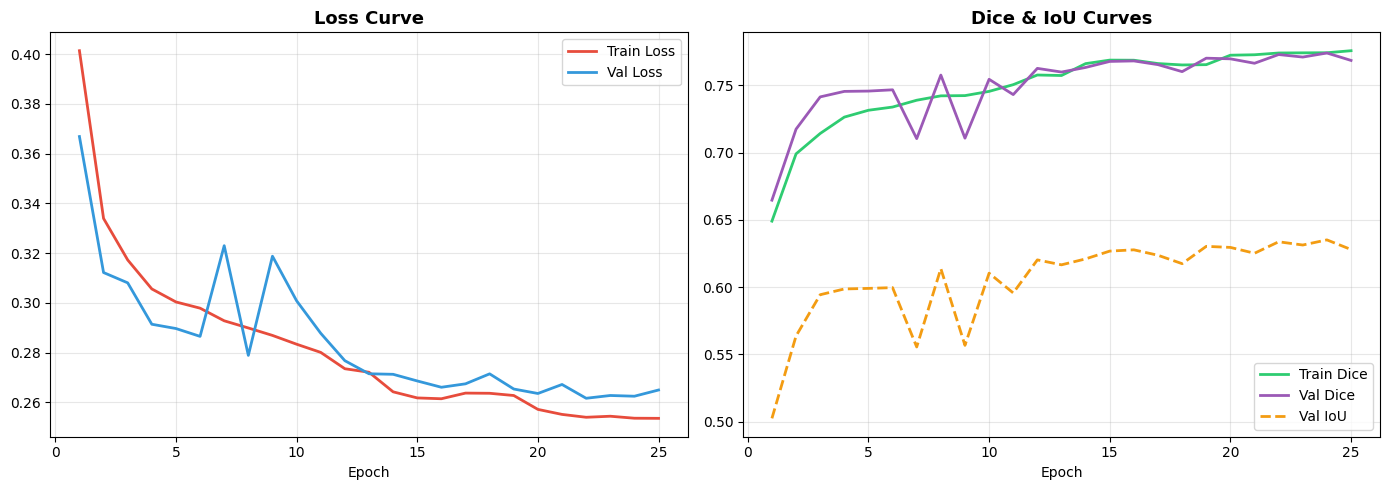

✅ Training history saved → /kaggle/working/training_history.png


In [13]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#3498db', linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_dice'], label='Train Dice', color='#2ecc71', linewidth=2)
axes[1].plot(epochs, history['val_dice'],   label='Val Dice',   color='#9b59b6', linewidth=2)
axes[1].plot(epochs, history['val_iou'],    label='Val IoU',    color='#f39c12', linewidth=2, linestyle='--')
axes[1].set_title('Dice & IoU Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved → /kaggle/working/training_history.png")

In [14]:
# Load best checkpoint
ckpt_path = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pth')
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']} | Dice: {checkpoint['best_dice']:.4f}\n")

# Evaluate
val_ds = ISICDataset(IMAGE_DIR, MASK_DIR, transform=get_val_transforms(CONFIG['img_size']))
val_ds.images = val_imgs   # restrict to the held-out split
total_dice, total_iou, total_acc = 0.0, 0.0, 0.0
n = len(val_ds)

with torch.no_grad():
    for i in tqdm(range(n), desc='Evaluating'):
        img, mask = val_ds[i]
        img  = img.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)
        with autocast():
            logits = model(img)
        total_dice += dice_score(logits, mask)
        total_iou  += iou_score(logits, mask)
        total_acc  += pixel_accuracy(logits, mask)

print(f"\n📊 Final Results ({n} samples):")
print(f"  Dice Score   : {total_dice/n:.4f}   (target > 0.85)")
print(f"  IoU Score    : {total_iou/n:.4f}   (target > 0.75)")
print(f"  Pixel Acc    : {total_acc/n:.4f}")

Loaded best model from epoch 24 | Dice: 0.7740



Evaluating:   0%|          | 0/390 [00:00<?, ?it/s]

/tmp/ipykernel_58/2761274850.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



📊 Final Results (390 samples):
  Dice Score   : 0.7349   (target > 0.85)
  IoU Score    : 0.6188   (target > 0.75)
  Pixel Acc    : 0.9052


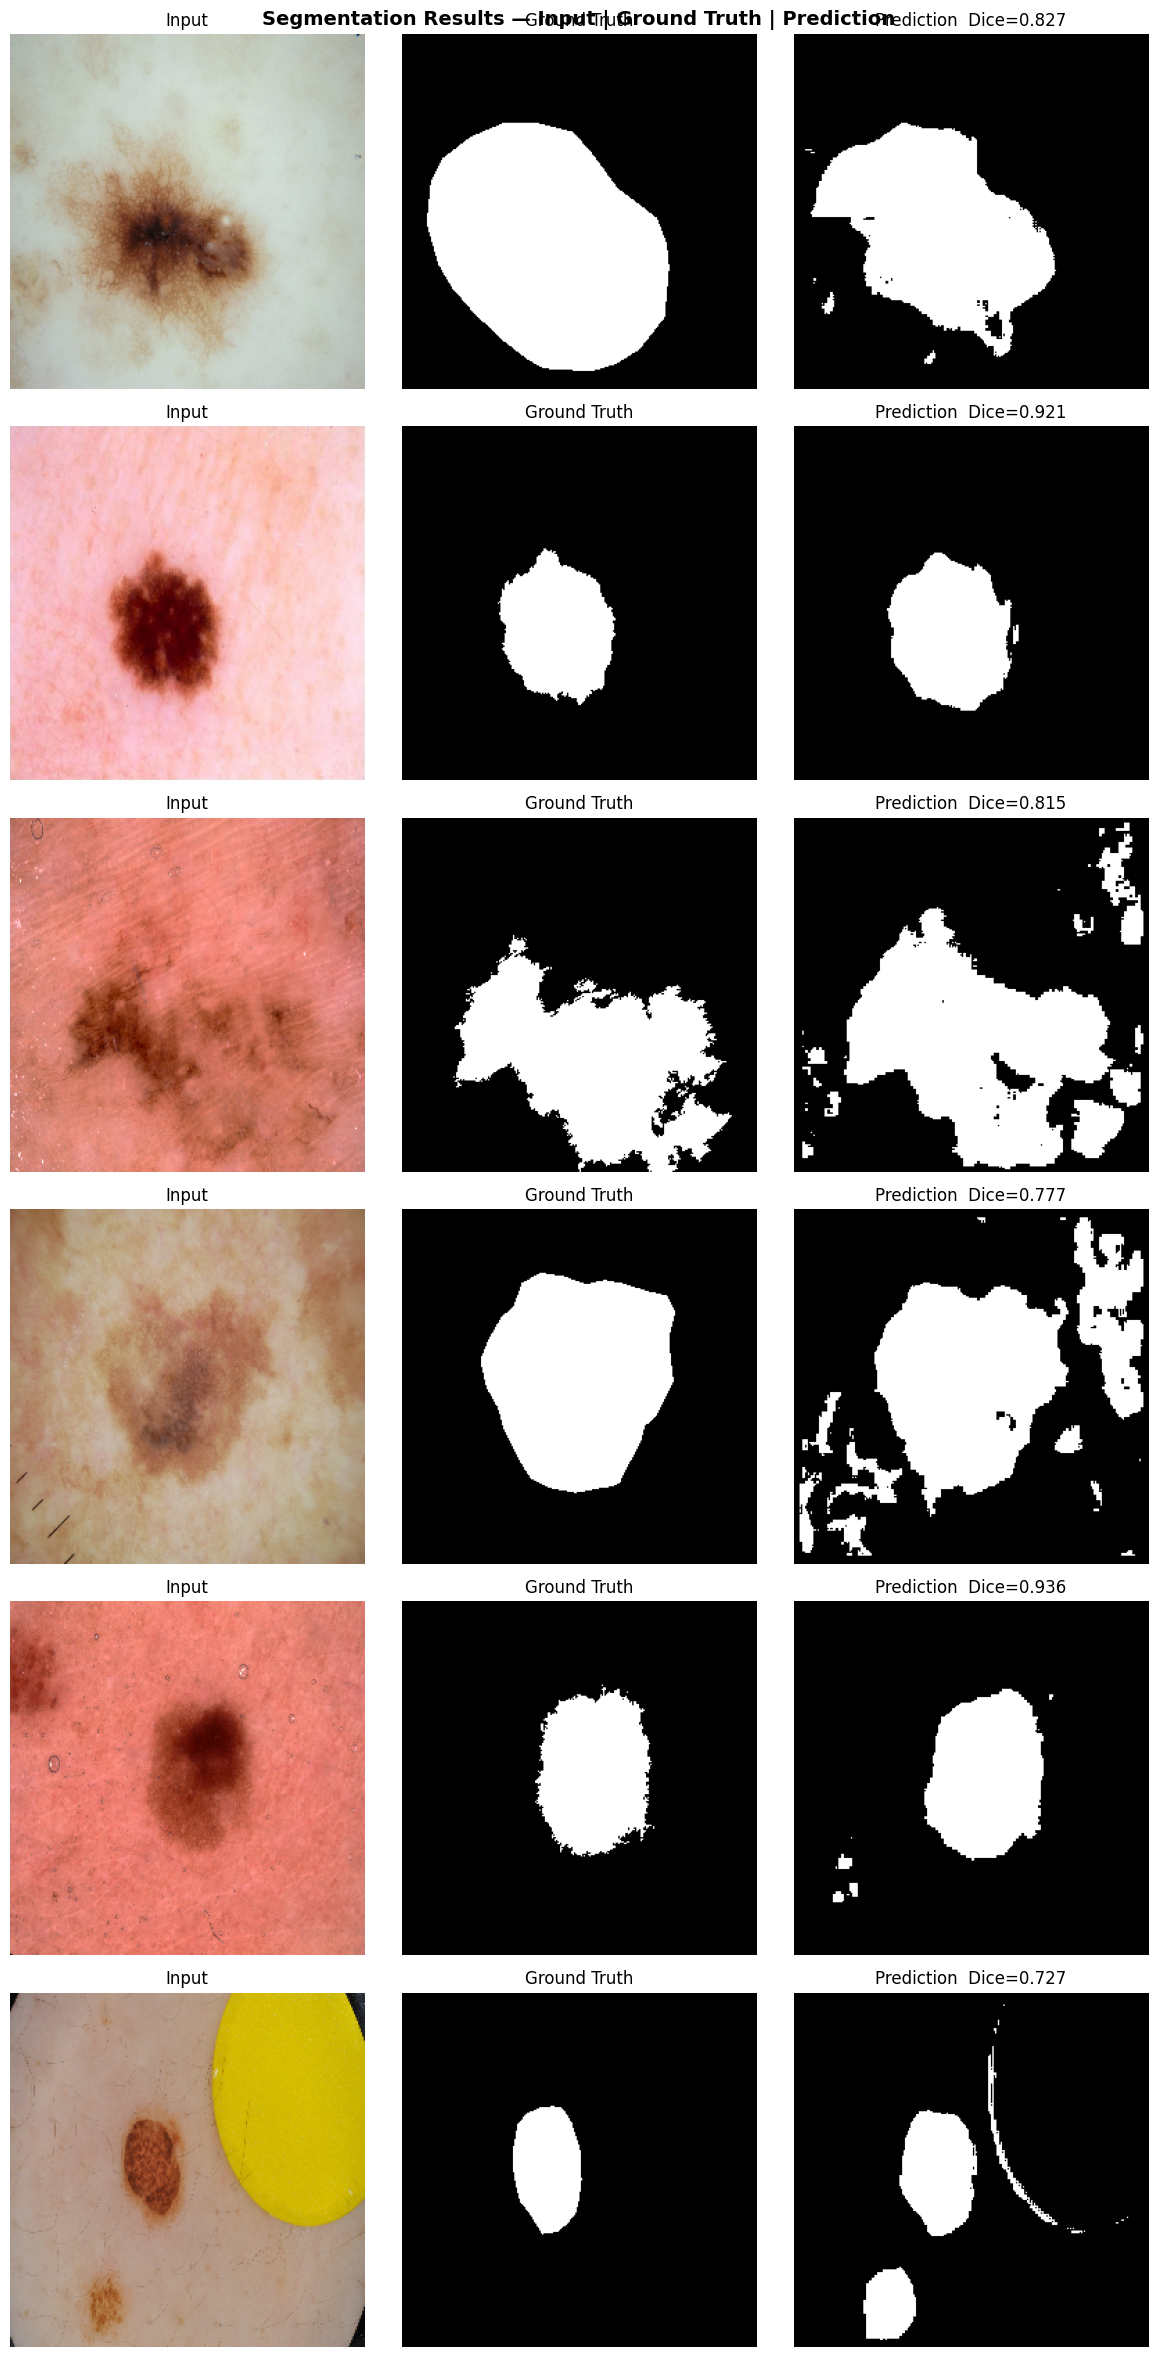

✅ Predictions saved → /kaggle/working/predictions.png


In [15]:
NUM_SAMPLES = 6
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

vis_ds  = ISICDataset(IMAGE_DIR, MASK_DIR, transform=get_val_transforms(CONFIG['img_size']))
indices = np.random.choice(len(vis_ds), NUM_SAMPLES, replace=False)

fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(12, NUM_SAMPLES * 4))
fig.suptitle('Segmentation Results — Input | Ground Truth | Prediction',
             fontsize=14, fontweight='bold')

model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        img, mask = vis_ds[idx]
        inp    = img.unsqueeze(0).to(device)
        logits = model(inp)
        pred   = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy()

        # Denormalize for display
        img_np  = np.clip(img.permute(1, 2, 0).numpy() * std + mean, 0, 1)
        mask_np = mask.squeeze().numpy()
        d       = dice_score(logits.cpu(), mask.unsqueeze(0))

        axes[row, 0].imshow(img_np);              axes[row, 0].set_title('Input')
        axes[row, 1].imshow(mask_np, cmap='gray'); axes[row, 1].set_title('Ground Truth')
        axes[row, 2].imshow(pred,    cmap='gray'); axes[row, 2].set_title(f'Prediction  Dice={d:.3f}')
        for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Predictions saved → /kaggle/working/predictions.png")

In [16]:
import shutil

shutil.make_archive(
    '/kaggle/working/final_project',
    'zip',
    '/kaggle/working'
)

print("✅ Created: /kaggle/working/final_project.zip")

OSError: [Errno 28] No space left on device

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024**2)
        if size_mb > 10:  # show files >10MB
            print(f"{size_mb:.2f} MB  {path}")

In [ ]:
import zipfile

zip_path = "/kaggle/working/project_release.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:

    z.write(
        "/kaggle/working/checkpoints/best_model.pth",
        "best_model.pth"
    )

    z.write(
        "/kaggle/working/training_history.png",
        "training_history.png"
    )

    z.write(
        "/kaggle/working/predictions.png",
        "predictions.png"
    )

    z.write(
        "/kaggle/working/sample_data.png",
        "sample_data.png"
    )

print("ZIP created")

In [ ]:
from IPython.display import FileLink, display

display(FileLink('/kaggle/working/project_release.zip'))